In [117]:
# Install NLP dependencies
!pip install -q nltk

# Imports
import pandas as pd
import numpy as np
import nltk
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# Download stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [118]:
# Mount your Google Drive if file is there
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv("/content/eCommerce_Customer_support_data.csv")
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [119]:
# Safe CSV loader (change path to your file)
df = df[['Customer Remarks', 'CSAT Score']]  # Keep only relevant columns
df.dropna(inplace=True)
df.head()


<ipython-input-119-a8cb48a6eba4>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


,Customer Remarks,CSAT Score
7,Very good,5
8,Shopzilla app and it's all coustomer care serv...,5
11,Very bad,1
17,Something,3
19,All good,5


In [120]:
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords if you haven't already
nltk.download('stopwords')

# Define stop_words
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-zA-Z]", " ", text)  # remove non-alphabetic characters
    text = re.sub(r"\s+", " ", text)  # remove extra spaces
    text = " ".join([word for word in text.split() if word not in stop_words])  # remove stopwords
    return text

# Now apply the function
df['cleaned_remarks'] = df['Customer Remarks'].apply(clean_text)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Customer Remarks,CSAT Score,cleaned_remarks
7,Very good,5,good
8,Shopzilla app and it's all coustomer care serv...,5,shopzilla app coustomer care services good ser...
11,Very bad,1,bad
17,Something,3,something
19,All good,5,good


In [121]:
# Tokenize and pad sequences
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_remarks'])
sequences = tokenizer.texts_to_sequences(df['cleaned_remarks'])

max_len = 100
X = pad_sequences(sequences, maxlen=max_len, padding='post')

# Labels (1–5)
y = df['CSAT Score'] - 1  # Make labels start from 0
# Import to_categorical
from tensorflow.keras.utils import to_categorical # This line is added to import the function
y_cat = to_categorical(y, num_classes=5)

In [122]:
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)


In [123]:
vocab_size = len(tokenizer.word_index) + 1

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')  # 5 output classes
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [124]:
history = model.fit(X_train, y_train, validation_split=0.1, epochs=5, batch_size=32)


Epoch 1/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 77s 108ms/step - accuracy: 0.7036 - loss: 0.9053 - val_accuracy: 0.7752 - val_loss: 0.7245
Epoch 2/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - accuracy: 0.7937 - loss: 0.6861 - val_accuracy: 0.7709 - val_loss: 0.7207
Epoch 3/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 93s 118ms/step - accuracy: 0.8049 - loss: 0.6324 - val_accuracy: 0.7657 - val_loss: 0.7504
Epoch 4/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.8155 - loss: 0.5855 - val_accuracy: 0.7630 - val_loss: 0.8000
Epoch 5/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 91s 121ms/step - accuracy: 0.8339 - loss: 0.5444 - val_accuracy: 0.7539 - val_loss: 0.8545


In [125]:
# Evaluate on test set
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")


180/180 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.7657 - loss: 0.7982
Test Accuracy: 75.98%


In [126]:
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print(classification_report(y_true_labels, y_pred_labels, digits=3))


180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step
              precision    recall  f1-score   support

           0      0.664     0.632     0.647      1030
           1      0.000     0.000     0.000        66
           2      0.036     0.007     0.011       146
           3      0.154     0.042     0.066       526
           4      0.804     0.928     0.861      3981

    accuracy                          0.760      5749
   macro avg      0.331     0.322     0.317      5749
weighted avg      0.690     0.760     0.719      5749



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [127]:
model.save("/content/csat_prediction_model.h5")


In [128]:
from sklearn.utils import class_weight
import numpy as np

# Convert y back to single-label form
y_int = np.argmax(y_cat, axis=1)

# Calculate class weights
weights = class_weight.compute_class_weight(class_weight='balanced',
                                             classes=np.unique(y_int),
                                             y=y_int)

class_weights = dict(enumerate(weights))
print(class_weights)


{0: np.float64(1.074869109947644), 1: np.float64(14.58984771573604), 2: np.float64(7.874520547945205), 3: np.float64(2.2083749519784863), 4: np.float64(0.29228657141404385)}


In [129]:
model.fit(X_train, y_train, validation_split=0.1, epochs=5, batch_size=32, class_weight=class_weights)


Epoch 1/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 77s 117ms/step - accuracy: 0.6721 - loss: 1.2744 - val_accuracy: 0.6026 - val_loss: 1.3735
Epoch 2/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 77s 120ms/step - accuracy: 0.6878 - loss: 1.0673 - val_accuracy: 0.4291 - val_loss: 1.4031
Epoch 3/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 73s 107ms/step - accuracy: 0.6832 - loss: 0.9052 - val_accuracy: 0.5878 - val_loss: 1.3954
Epoch 4/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 78s 101ms/step - accuracy: 0.7271 - loss: 0.7973 - val_accuracy: 0.5987 - val_loss: 1.4445
Epoch 5/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 64s 100ms/step - accuracy: 0.7105 - loss: 0.7793 - val_accuracy: 0.6009 - val_loss: 1.4501


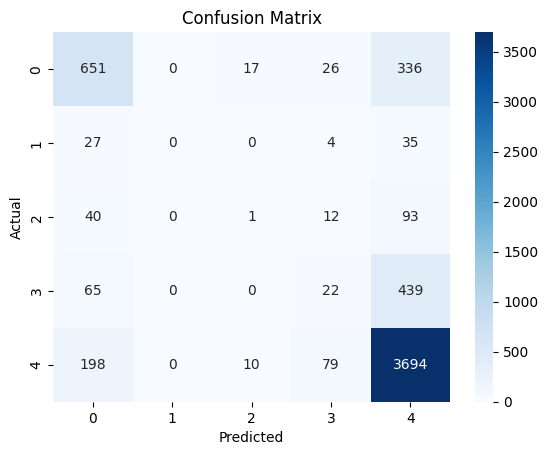

In [130]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_labels, y_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [131]:
from sklearn.utils import class_weight
import numpy as np

y_train_int = np.argmax(y_train, axis=1)
weights = class_weight.compute_class_weight(class_weight='balanced',
                                             classes=np.unique(y_train_int),
                                             y=y_train_int)

class_weights = dict(enumerate(weights))
print(class_weights)


{0: np.float64(1.064983788791107), 1: np.float64(14.020121951219512), 2: np.float64(7.874315068493151), 3: np.float64(2.2140587385652384), 4: np.float64(0.29316588040290703)}


In [132]:
model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    class_weight=class_weights
)


Epoch 1/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 65s 100ms/step - accuracy: 0.7108 - loss: 0.7177 - val_accuracy: 0.5787 - val_loss: 1.5880
Epoch 2/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 82s 100ms/step - accuracy: 0.7203 - loss: 0.7272 - val_accuracy: 0.5752 - val_loss: 1.5822
Epoch 3/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 81s 100ms/step - accuracy: 0.7041 - loss: 0.6573 - val_accuracy: 0.5948 - val_loss: 1.5825
Epoch 4/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 65s 100ms/step - accuracy: 0.6982 - loss: 0.6791 - val_accuracy: 0.5896 - val_loss: 1.7054
Epoch 5/5
647/647 ━━━━━━━━━━━━━━━━━━━━ 65s 100ms/step - accuracy: 0.7064 - loss: 0.6610 - val_accuracy: 0.5700 - val_loss: 1.6962


In [133]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip


--2025-04-30 17:28:23--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-04-30 17:28:23--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-04-30 17:28:23--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.2’

gl

In [134]:
embedding_index = {}

with open("glove.6B.100d.txt", encoding="utf8") as f:  # or "glove.6B.50d.txt"
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector

print(f"Loaded {len(embedding_index)} word vectors.")


Loaded 400000 word vectors.


In [135]:
embedding_dim = 100  # Or 50, if you chose 50d

word_index = tokenizer.word_index  # from your Tokenizer
num_words = min(len(word_index) + 1, 10000)

embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    if i < num_words:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector


In [136]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

model = Sequential([
    Embedding(input_dim=num_words,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=X_train.shape[1],
              trainable=False),  # freeze embeddings
    GlobalAveragePooling1D(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(y_train.shape[1], activation='softmax')
])

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [137]:
model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    class_weight=class_weights
)


Epoch 1/10
647/647 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4205 - loss: 1.6219 - val_accuracy: 0.5943 - val_loss: 1.5203
Epoch 2/10
647/647 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5773 - loss: 1.5633 - val_accuracy: 0.5974 - val_loss: 1.4525
Epoch 3/10
647/647 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5850 - loss: 1.5419 - val_accuracy: 0.5939 - val_loss: 1.3925
Epoch 4/10
647/647 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5772 - loss: 1.5175 - val_accuracy: 0.5839 - val_loss: 1.4172
Epoch 5/10
647/647 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5505 - loss: 1.5240 - val_accuracy: 0.5870 - val_loss: 1.3395
Epoch 6/10
647/647 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5503 - loss: 1.5247 - val_accuracy: 0.5974 - val_loss: 1.3293
Epoch 7/10
647/647 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5766 - loss: 1.4705 - val_accuracy: 0.6017 - val_loss: 1.3124
Epoch 8/10
647/647 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5837 - loss: 1.4616 - val_accuracy: 0.

In [138]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5503 - loss: 1.3943
Test Accuracy: 55.07%


In [139]:
from sklearn.metrics import classification_report
import numpy as np

y_pred_probs = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print(classification_report(y_true_labels, y_pred_labels, digits=3))


180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0      0.565     0.540     0.552      1030
           1      0.026     0.348     0.049        66
           2      0.053     0.233     0.087       146
           3      0.120     0.097     0.107       526
           4      0.883     0.628     0.734      3981

    accuracy                          0.551      5749
   macro avg      0.330     0.369     0.306      5749
weighted avg      0.725     0.551     0.620      5749



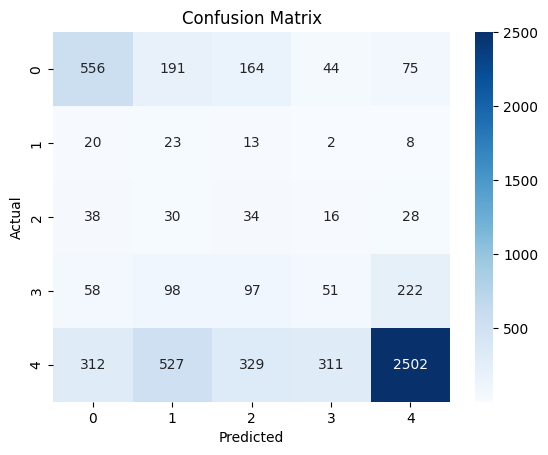

In [140]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_labels, y_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [141]:
from sklearn.model_selection import train_test_split

# Split the training data into training and validation sets (e.g., 80-20 split)
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Now train on the split set
# Use 'class_weights' instead of 'class_weights_dict'
model.fit(
    X_train_split,
    y_train_split,
    epochs=10,
    validation_data=(X_val, y_val),
    class_weight=class_weights
)

Epoch 1/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5634 - loss: 1.4365 - val_accuracy: 0.5584 - val_loss: 1.3467
Epoch 2/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5540 - loss: 1.4683 - val_accuracy: 0.5425 - val_loss: 1.4146
Epoch 3/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5481 - loss: 1.4565 - val_accuracy: 0.5616 - val_loss: 1.3428
Epoch 4/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5714 - loss: 1.4208 - val_accuracy: 0.5540 - val_loss: 1.3651
Epoch 5/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5619 - loss: 1.4850 - val_accuracy: 0.5645 - val_loss: 1.3415
Epoch 6/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5637 - loss: 1.4482 - val_accuracy: 0.5679 - val_loss: 1.3185
Epoch 7/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5804 - loss: 1.4079 - val_accuracy: 0.5416 - val_loss: 1.3452
Epoch 8/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5415 - loss: 1.4734 - val_accuracy: 0.

In [142]:
history = model.fit(
    X_train_split,
    y_train_split,
    epochs=10,
    validation_data=(X_val, y_val),
    class_weight=class_weights # Changed 'class_weights_dict' to 'class_weights'
)

Epoch 1/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5601 - loss: 1.4447 - val_accuracy: 0.5621 - val_loss: 1.3273
Epoch 2/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5527 - loss: 1.4398 - val_accuracy: 0.5577 - val_loss: 1.3159
Epoch 3/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5466 - loss: 1.4564 - val_accuracy: 0.5762 - val_loss: 1.2991
Epoch 4/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5525 - loss: 1.4273 - val_accuracy: 0.5597 - val_loss: 1.3334
Epoch 5/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5495 - loss: 1.4094 - val_accuracy: 0.5447 - val_loss: 1.3475
Epoch 6/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5544 - loss: 1.4026 - val_accuracy: 0.5358 - val_loss: 1.3530
Epoch 7/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5315 - loss: 1.4410 - val_accuracy: 0.5510 - val_loss: 1.3490
Epoch 8/10
575/575 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5560 - loss: 1.4289 - val_accuracy: 0.

In [143]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2%}")


180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5752 - loss: 1.2898
Test Accuracy: 57.09%


In [144]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print(classification_report(y_true_labels, y_pred_labels, digits=3))


180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
              precision    recall  f1-score   support

           0      0.628     0.494     0.553      1030
           1      0.031     0.424     0.058        66
           2      0.050     0.233     0.082       146
           3      0.146     0.089     0.111       526
           4      0.878     0.669     0.760      3981

    accuracy                          0.571      5749
   macro avg      0.347     0.382     0.313      5749
weighted avg      0.736     0.571     0.638      5749



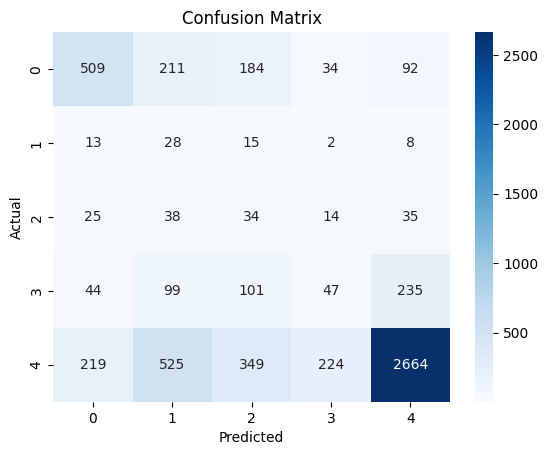

In [145]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_labels, y_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



In [146]:
model.save("/content/final_csat_model.h5")


In [147]:
from sklearn.metrics import classification_report

print(classification_report(y_true_labels, y_pred_labels, digits=3))


              precision    recall  f1-score   support

           0      0.628     0.494     0.553      1030
           1      0.031     0.424     0.058        66
           2      0.050     0.233     0.082       146
           3      0.146     0.089     0.111       526
           4      0.878     0.669     0.760      3981

    accuracy                          0.571      5749
   macro avg      0.347     0.382     0.313      5749
weighted avg      0.736     0.571     0.638      5749



In [148]:
from tensorflow.keras.models import load_model
import numpy as np
import pickle

MAX_LEN = 100
# 1. Load the saved model
model = load_model("/content/final_csat_model.h5")

# 2. Prepare your sample input
sample_text = "customer service is good."
with open('/content/tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# 3. Preprocess it exactly as you did for training (tokenization + padding)
# Example if using Tokenizer + pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Use the same tokenizer as training (replace with your loaded tokenizer)
# Assuming you have a saved tokenizer JSON or pickle from training
import pickle
with open('/content/tokenizer.pkl', 'rb') as handle:
    tokenizer = pickle.load(handle)

# Tokenize and pad
seq = tokenizer.texts_to_sequences([sample_text])
padded = pad_sequences(seq, maxlen=MAX_LEN)  # Use same MAX_LEN as during training

# 4. Predict
pred = model.predict(padded)
predicted_class = np.argmax(pred, axis=1)[0]

print("Predicted CSAT Class:", predicted_class + 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Predicted CSAT Class: 5


In [149]:
sample_inputs = [
    "I'm really unhappy with the service.",  # Expect low score
    "It was okay, not great.",              # Expect mid score
    "Absolutely amazing experience!"        # Expect high score
]

# Preprocess as before
sequences = tokenizer.texts_to_sequences(sample_inputs)
padded_inputs = pad_sequences(sequences, maxlen=MAX_LEN)

# Predict
predictions = model.predict(padded_inputs)
predicted_scores = np.argmax(predictions, axis=1)
print(predicted_scores + 1)  # +1 if your scores are 1–5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
[1 5 5]


In [150]:
# New labels: 0 for [1,2,3,4], 1 for [5]
# Assuming 'CSAT Score' is the correct column name
df['csat_binary'] = df['CSAT Score'].apply(lambda x: 1 if x == 5 else 0)

In [151]:
Dense(1, activation='sigmoid')


<Dense name=dense_12, built=False>

In [152]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)


In [153]:
# Convert labels: 1–4 → 0 (not satisfied), 5 → 1 (satisfied)
df['csat_binary'] = df['CSAT Score'].apply(lambda x: 1 if x == 5 else 0) # Changed 'csat_score' to 'CSAT Score'

In [154]:
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


In [155]:
import pandas as pd

predicted_labels = np.argmax(model.predict(X_test), axis=1) + 1

# Get the indices of the test set from the original DataFrame
test_indices = y_test.nonzero()[0] # Assuming y_test is one-hot encoded, find the non-zero indices

original_texts = df['Customer Remarks'].iloc[test_indices].tolist()  # Get original texts using test indices

results_df = pd.DataFrame({
    "Customer_Remarks": original_texts,
    "True_Label": np.argmax(y_test, axis=1) + 1,  # Get true labels from y_test
    "Predicted_Label": predicted_labels
})
results_df.to_csv("csat_predictions.csv", index=False)

180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [156]:
sample_inputs = [
    "I'm really unhappy with the service.",  # Expect low score
    "It was okay, not great.",              # Expect mid score
    "Absolutely amazing experience!"        # Expect high score
]

# Preprocess as before
sequences = tokenizer.texts_to_sequences(sample_inputs)
padded_inputs = pad_sequences(sequences, maxlen=MAX_LEN)

# Predict
predictions = model.predict(padded_inputs)
predicted_scores = np.argmax(predictions, axis=1)
print(predicted_scores + 1)  # +1 if your scores are 1–5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[1 1 1]


In [157]:
from keras.models import load_model
model = load_model("/content/final_csat_model.h5")


In [158]:
# Instead of this:
# sequences = tokenizer.texts_to_sequences(df['Customer_Remarks'])

# Use the correct column name. Assuming it was renamed to 'cleaned_remarks':
sequences = tokenizer.texts_to_sequences(df['cleaned_remarks'])
padded_inputs = pad_sequences(sequences, maxlen=MAX_LEN)

In [159]:
predictions = model.predict(padded_inputs)
predicted_scores = np.argmax(predictions, axis=1) + 1


899/899 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [160]:
from keras.models import load_model
from keras.preprocessing.sequence import pad_sequences
import pandas as pd
import numpy as np

# Load model and tokenizer (assuming tokenizer is already available)
model = load_model("/content/final_csat_model.h5")

# Load data
df = pd.read_csv("/content/csat_predictions.csv")  # replace with actual file

# Preprocess
sequences = tokenizer.texts_to_sequences(df["Customer_Remarks"])
padded_inputs = pad_sequences(sequences, maxlen=MAX_LEN)

# Predict
predictions = model.predict(padded_inputs)
predicted_scores = np.argmax(predictions, axis=1) + 1  # for 1–5 scale

# Save to CSV
df["Predicted_Score"] = predicted_scores
df.to_csv("csat_predictions_output.csv", index=False)


180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [161]:
# Test with a known sample input
sample_text = "The product quality was bad"
seq = tokenizer.texts_to_sequences([sample_text])
padded_sample = pad_sequences(seq, maxlen=MAX_LEN)

# Get prediction probabilities
pred_probs = model.predict(padded_sample)
print("Raw prediction probabilities:", pred_probs)

# Get the predicted class for a 5-class output (assuming classes 0-4 map to 1-5)
pred_class = np.argmax(pred_probs, axis=1)[0] + 1
print("Predicted CSAT Score:", pred_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Raw prediction probabilities: [[0.32857427 0.20302597 0.19867484 0.15579723 0.11392776]]
Predicted CSAT Score: 1


In [162]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = " ".join(word for word in text.split() if word not in stop_words)
    return text

sample_text_clean = clean_text(sample_text)
seq = tokenizer.texts_to_sequences([sample_text_clean])
padded_sample = pad_sequences(seq, maxlen=MAX_LEN)


In [163]:
print(df.columns)  # Check available columns
print(df.head())  # Check the first few rows to get column names

Index(['Customer_Remarks', 'True_Label', 'Predicted_Label', 'Predicted_Score'], dtype='object')
                                    Customer_Remarks  True_Label  \
0                                          Very good           4   
1  Shopzilla app and it's all coustomer care serv...           5   
2                                           Very bad           1   
3                                         Something            4   
4                                           All good           5   

   Predicted_Label  Predicted_Score  
0                1                5  
1                1                3  
2                1                1  
3                1                4  
4                1                5  


In [164]:
print(df['Predicted_Label'].value_counts())

Predicted_Label
1    5749
Name: count, dtype: int64


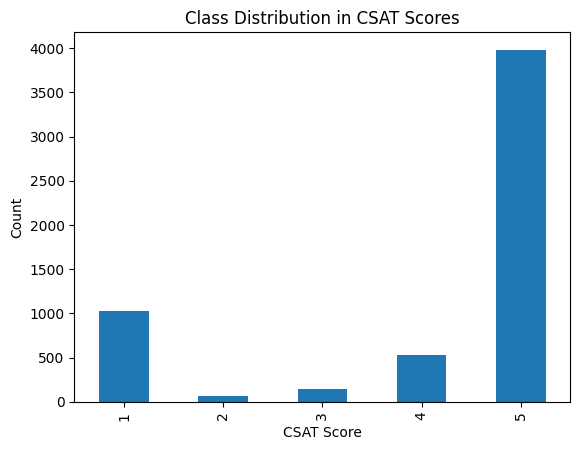

In [165]:
import matplotlib.pyplot as plt
df['True_Label'].value_counts().sort_index().plot(kind='bar') # Changed 'CSAT Score' to 'True_Label'
plt.title('Class Distribution in CSAT Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Count')
plt.show()

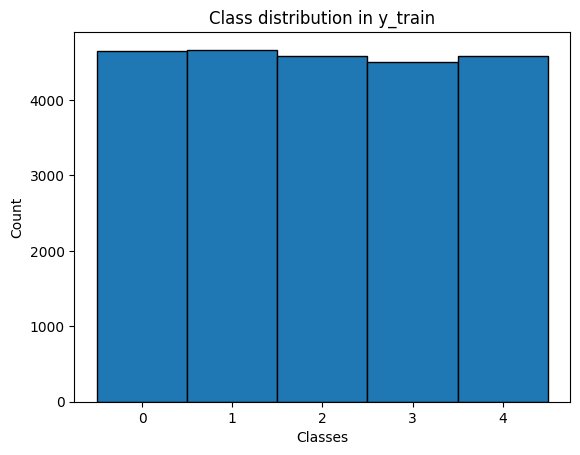

In [166]:
import numpy as np
import matplotlib.pyplot as plt

# assuming y_train_labels is available
plt.hist(y_train_labels, bins=np.arange(6)-0.5, edgecolor='black')
plt.xticks([0, 1, 2, 3, 4])
plt.title("Class distribution in y_train")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()


In [167]:
pip install imbalanced-learn


In [171]:
from imblearn.over_sampling import RandomOverSampler

# X is already a NumPy array, no need for .values
X_resampled = X.reshape((X.shape[0], -1))  # Reshape for RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_balanced, y_balanced = ros.fit_resample(X_resampled, y_train_labels)

# Reshape back to original shape if needed
X_balanced = X_balanced.reshape((-1, X.shape[1]))
y_balanced = tf.keras.utils.to_categorical(y_balanced, num_classes=5)  # One-hot encode

In [175]:
import tensorflow as tf

# For TensorFlow 1.x environments, enable eager execution
tf.compat.v1.enable_eager_execution()

# Or create a TensorFlow dataset to avoid NumPy conversion issues
dataset = tf.data.Dataset.from_tensor_slices((X_balanced, y_balanced))
dataset = dataset.batch(64)

model.fit(
    dataset,
    epochs=10,
    validation_split=0.2  # Note: validation_split might not work with Dataset objects
)

ValueError: Dimensions 29084 and 23335 are not compatible

In [176]:
from imblearn.over_sampling import RandomOverSampler

# Convert y_train_labels back to categorical (one-hot encoded) format
y_train_cat = tf.keras.utils.to_categorical(y_train_labels, num_classes=5)

# Reshape X if needed for your model type (e.g., RNNs, CNNs)
# This is a general example, adjust based on your model's input shape


In [177]:
y_labels = np.argmax(y_train, axis=1)


In [181]:
import pandas as pd
from sklearn.utils import resample

# Combine X and y into a DataFrame
X_df = pd.DataFrame(X)  # If X is array-like
y_df = pd.DataFrame(y_labels, columns=['label'])
combined = pd.concat([X_df, y_df], axis=1)

# Get minimum class count
min_count = combined['label'].value_counts().min()

# Undersample all classes to min_count, but ensure n_samples is at least 1
balanced_df = pd.concat([
    resample(combined[combined['label'] == i],
             replace=False,  # Sample without replacement
             n_samples=min(min_count, combined[combined['label'] == i].shape[0]),  # Use minimum between min_count and actual class size
             random_state=42)
    for i in combined['label'].unique() if combined[combined['label'] == i].shape[0] > 0 # Add condition to only resample if class has samples
])

# Shuffle and split again
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

X_bal = balanced_df.drop(columns='label').values
y_bal = tf.keras.utils.to_categorical(balanced_df['label'].values, num_classes=5)

In [183]:
# Re-initialize and recompile the model before training with new data.

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

# Load the embedding matrix (if you were using pre-trained embeddings)
# ...

model = Sequential([
    Embedding(input_dim=num_words,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=X_train.shape[1],
              trainable=False),
    GlobalAveragePooling1D(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(y_train.shape[1], activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Now, fit the model with your balanced data
model.fit(
    X_bal,
    y_bal,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
 1/21 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.2500 - loss: 1.6106

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.2048 - loss: 1.6094 - val_accuracy: 0.1890 - val_loss: 1.6128
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.2100 - loss: 1.6088 - val_accuracy: 0.1951 - val_loss: 1.6138
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.2191 - loss: 1.6065 - val_accuracy: 0.2012 - val_loss: 1.6165
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.2181 - loss: 1.6047 - val_accuracy: 0.1829 - val_loss: 1.6179
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.2454 - loss: 1.6059 - val_accuracy: 0.1799 - val_loss: 1.6173
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.2300 - loss: 1.6048 - val_accuracy: 0.1677 - val_loss: 1.6185
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.2261 - loss: 1.6052 - val_accuracy: 0.1585 - val_loss: 1.6189
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.2400 - loss: 1.6039 - val_accuracy: 0.1707 - val_loss: 1.

In [184]:
# Predict probabilities
y_pred_probs = model.predict(X_val)

# Convert probabilities to class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded true labels to class labels
y_true_labels = np.argmax(y_val, axis=1)


144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.15      0.59      0.25       880
           1       0.00      0.00      0.00        63
           2       0.02      0.04      0.03       109
           3       0.09      0.18      0.12       451
           4       0.48      0.01      0.02      3096

    accuracy                           0.14      4599
   macro avg       0.15      0.16      0.08      4599
weighted avg       0.36      0.14      0.07      4599



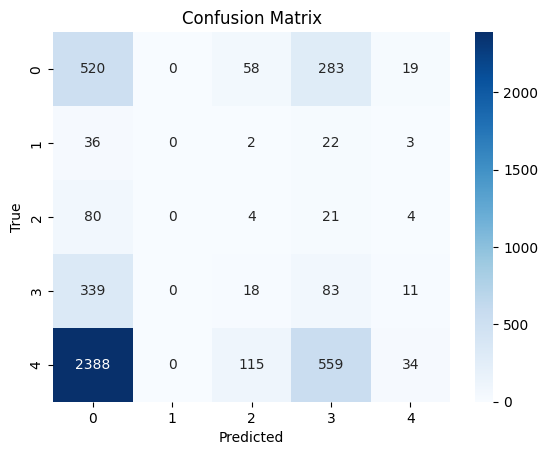

In [185]:
from sklearn.metrics import classification_report, confusion_matrix

# Classification report
print(classification_report(y_true_labels, y_pred_labels))

# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [205]:
import pandas as pd  # Import pandas if not already imported

# ... (your existing code)

# Before assigning to df_test, create it!
df_test = pd.DataFrame()  # Create an empty DataFrame

# Now you can add columns
df_test['Predicted_Label'] = y_pred_labels
df_test['True_Label'] = y_true_labels

df_test.head(8
             )

,Predicted_Label,True_Label
0,0,4
1,0,4
2,0,4
3,0,4
4,0,4
5,3,0
6,0,3
7,3,4


In [202]:
# Sample input
test_remark = ["Very satisfied with customer service"]

# Preprocess it using the same tokenizer as training
# Use tokenizer.texts_to_sequences to convert text to sequences
test_sequences = tokenizer.texts_to_sequences(test_remark)

# Pad the sequences using the same MAX_LEN as during training
test_vector = pad_sequences(test_sequences, maxlen=MAX_LEN)

# Predict
prediction_probs = model.predict(test_vector)
predicted_label = np.argmax(prediction_probs)

print("Predicted Label:", predicted_label + 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Label: 4


In [209]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# If y is already label-encoded (e.g., 0, 1, 2, 3, 4), no need for np.argmax
y_labels = y  # Use y directly if it's 1D

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y_labels)

# Convert to one-hot
y_resampled_cat = to_categorical(y_resampled, num_classes=5)

# Split
X_train, X_val, y_train, y_val = train_test_split(X_resampled, y_resampled_cat, test_size=0.2, random_state=42)

# Train model
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=5)


Epoch 1/5
   1/2459 ━━━━━━━━━━━━━━━━━━━━ 2:40 65ms/step - accuracy: 0.1250 - loss: 1.6175

/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


2459/2459 ━━━━━━━━━━━━━━━━━━━━ 125s 51ms/step - accuracy: 0.2720 - loss: 1.5665 - val_accuracy: 0.3315 - val_loss: 1.5056
Epoch 2/5
2459/2459 ━━━━━━━━━━━━━━━━━━━━ 140s 50ms/step - accuracy: 0.3250 - loss: 1.5067 - val_accuracy: 0.3386 - val_loss: 1.4766
Epoch 3/5
2459/2459 ━━━━━━━━━━━━━━━━━━━━ 144s 51ms/step - accuracy: 0.3270 - loss: 1.4947 - val_accuracy: 0.3443 - val_loss: 1.4655
Epoch 4/5
2459/2459 ━━━━━━━━━━━━━━━━━━━━ 139s 50ms/step - accuracy: 0.3344 - loss: 1.4826 - val_accuracy: 0.3452 - val_loss: 1.4574
Epoch 5/5
2459/2459 ━━━━━━━━━━━━━━━━━━━━ 141s 50ms/step - accuracy: 0.3389 - loss: 1.4735 - val_accuracy: 0.3480 - val_loss: 1.4519


In [221]:
# Select a few samples from the validation set
sample_idx = [0, 1, 2]  # you can change these indexes
sample_inputs = X_val[sample_idx]

# Get predicted probabilities and class labels
pred_probs = model.predict(sample_inputs)
pred_classes = np.argmax(pred_probs, axis=1)

print("Predicted Class Labels:", pred_classes)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted Class Labels: [0 4 0]


In [211]:
# Predict on the entire validation set
val_preds = model.predict(X_val)
val_classes = np.argmax(val_preds, axis=1)

# View prediction class distribution
import numpy as np
unique, counts = np.unique(val_classes, return_counts=True)
print("Class distribution in predictions:")
print(dict(zip(unique, counts)))


615/615 ━━━━━━━━━━━━━━━━━━━━ 61s 99ms/step
Class distribution in predictions:
{np.int64(0): np.int64(4521), np.int64(1): np.int64(4779), np.int64(2): np.int64(2121), np.int64(3): np.int64(1798), np.int64(4): np.int64(6448)}


In [212]:
custom_text = "Thank you for your help, everything works fine now!"


In [219]:
# Example input text
sample_text = ["The agent was very helpful and resolved my issue quickly."]

# Preprocess if needed (like lowercasing, removing punctuation, etc.)
# Only if your training set was preprocessed — otherwise skip

# Transform using your fitted vectorizer (e.g., tfidf_vectorizer)
sample_vectorized = tfidf_vectorizer.transform(sample_text)

# Predict
prediction = model.predict(sample_vectorized)
predicted_class = np.argmax(prediction, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


In [228]:
sample_text = ["Thank you for your help, everything works fine now!"]
sample_vectorized = tfidf_vectorizer.transform(sample_text)
prediction = model.predict(sample_vectorized)
predicted_class = np.argmax(prediction, axis=1)

print(f"Predicted CSAT Score: {predicted_class[0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Predicted CSAT Score: 3


In [229]:
from collections import Counter
print("Class distribution after SMOTE:", Counter(y_resampled))


Class distribution after SMOTE: Counter({4: 19667, 0: 19667, 2: 19667, 3: 19667, 1: 19667})


In [230]:
val_labels = np.argmax(y_val, axis=1)
print("Validation class distribution:", Counter(val_labels))


Validation class distribution: Counter({np.int64(0): 4009, np.int64(2): 3974, np.int64(4): 3937, np.int64(1): 3919, np.int64(3): 3828})


In [231]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [234]:
test_cases = [
    "Agent was extremely rude and didn't solve my issue at all.",  # Should be class 0 or 1
    "My issue was partially resolved, but I had to call back.",    # Class 2
    "The help was decent, nothing extraordinary.",                 # Class 3
    "Amazing service! Super helpful and polite agent."             # Class 4
]

for text in test_cases:
    vec = tfidf_vectorizer.transform([text])
    pred = model.predict(vec)
    print(f"Text: {text}\nPredicted Class: {np.argmax(pred)}\n")


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
Text: Agent was extremely rude and didn't solve my issue at all.
Predicted Class: 4

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Text: My issue was partially resolved, but I had to call back.
Predicted Class: 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
Text: The help was decent, nothing extraordinary.
Predicted Class: 3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Text: Amazing service! Super helpful and polite agent.
Predicted Class: 4



In [233]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Get the input shape from the tfidf_vectorizer
input_shape = tfidf_vectorizer.transform(["test"]).shape[1]

model = Sequential([
    Input(shape=(input_shape,)),  # Use Input layer to specify shape
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

In [235]:
import joblib
model.save("csat_model.h5")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']